![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 1. Waveguides

Welcome to our Photonic Integrated Circuits Laboratory! Throughout the course, we will be using a Python package called [GDSFactory](https://gdsfactory.github.io/gdsfactory/index.html). This is an open-source tool, and is a great alternative to other commercial software like Synopsys Optodesigner, Luceda Photonics, or Lumerical/Interconnect. Since it runs on Python, you have two options for executing your laboratory tasks:

1. **Local installation on your own PC** (Recommended): Please note that we will not spend class time on installing the software. However, feel free to reach out if you need help with the installation.

2. **Cloud Workspace**: Alternatively, you can use a cloud-based solution if the Local installation does not work.

## 0. Imports

For this laboratory you will need the following libraries:

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength


## LO.1. Effective index of a waveguide

### 1.1. Materials

We need the refractive index of each material in the cross-section. There are different options to get this information, such as [RefractiveIndex.info](https://refractiveindex.info/) and the [Material Library from Tidy3D](https://docs.flexcompute.com/projects/tidy3d/en/v2.6.0/api/material_library.html#). Here we will load and check the characteristics from the most common materials used in fabrication of photonic circuits: **silicon (Si), silicon nitride (SiNx) and silicon dioxide (SiO2)**.

#### 1.1.1. Crystalline Silicon 

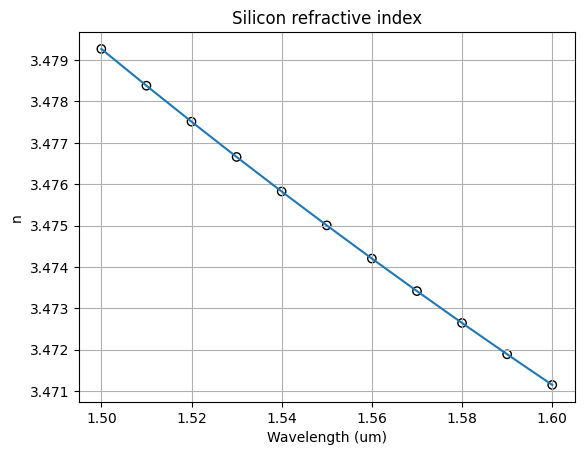

In [2]:
## Material model loaded
si_complex = td.material_library["cSi"]["Li1993_293K"].eps_model(f)
## Check the Tidy3D Docs for more information on the "Variant"

## Index at a particular wavelength
si_index , si_k = td.Medium.eps_complex_to_nk(si_complex)
plt.scatter(wavelength, si_index,edgecolors='k',facecolors='none')
plt.plot(wavelength,si_index)
plt.title("Silicon refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()

#### 1.1.2. Silicon Nitride

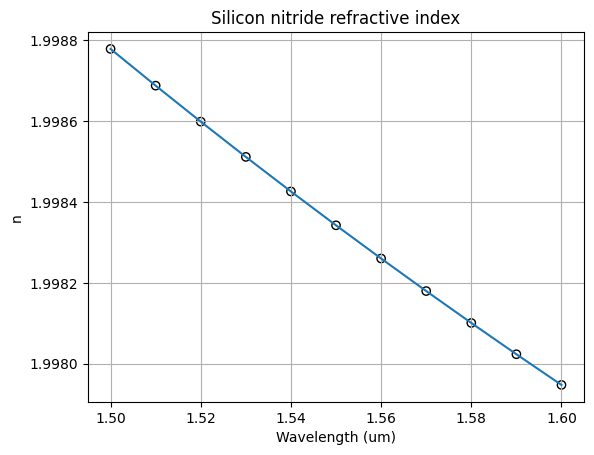

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
plt.scatter(wavelength,nitride_index,edgecolors='k',facecolors='none')
plt.plot(wavelength, nitride_index)
plt.title("Silicon nitride refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()


#### 1.1.3. Silicon Dioxide

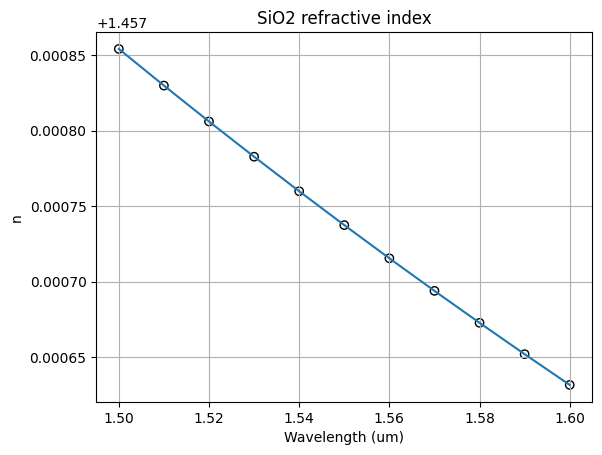

In [4]:
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)
plt.scatter(wavelength,box_index,edgecolors='k',facecolors='None')
plt.plot(wavelength, box_index)
plt.title("SiO2 refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()

### 1.2. Cross - Section Definition

In GDSFactory - Tidy3d modesolver we just have to use the [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. 
It implements the **deep (rib)** and **shallow (ridge)** waveguide variants. The following example corresponds to a **deep** waveguide for the **silicon nitride** fabrication proccess, this means that the **cladding** material is silicon dioxide and the **core** material is silicon nitride. The waveguide dimensions are 300 nm (height) and 1.2 um (width). We will check it's behavior at 1.55 um. 

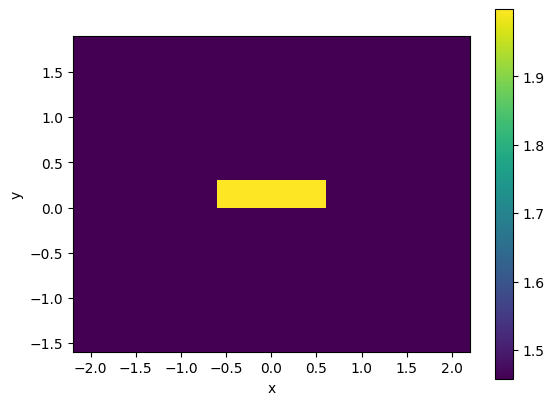

In [5]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()

### 1.3. Simulations

#### 1.3.1. Numerical results

We can find the effective index (n_eff), TE and TM fraction for each particular cross-section.

In [6]:
deep_waveguide.n_eff

2026-03-12 18:33:20.235 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cf92515ae4232c65.npz.


array([1.60524792+0.00010066j, 1.52829803+0.00017753j,
       1.45072999+0.00019228j, 1.43325817+0.00021838j])

In [7]:
deep_waveguide.fraction_te

array([0.99505426, 0.01004259, 0.96264794, 0.047651  ])

In [8]:
deep_waveguide.fraction_tm

array([0.00494574, 0.98995741, 0.03735206, 0.952349  ])

#### 1.3.4. Plots

Text(0.5, 1.0, 'Modo 0 (TE)')

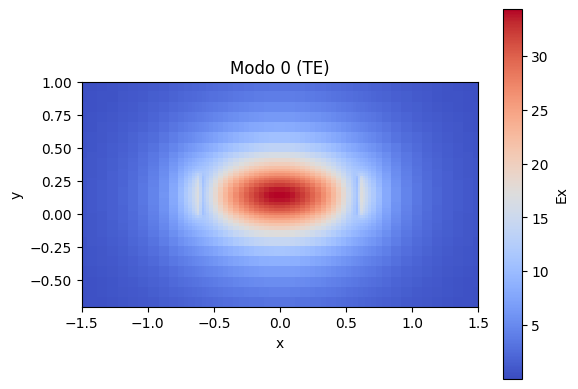

In [9]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('Modo 0 (TE)') # You might need this later :) 

Text(0.5, 1.0, 'Modo 1 (TM)')

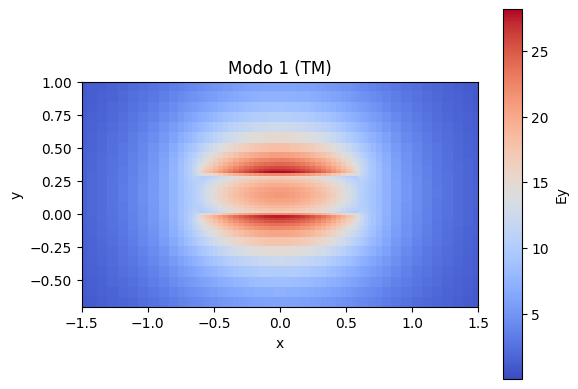

In [10]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
plt.title('Modo 1 (TM)')

Text(0.5, 1.0, 'Modo 2 (TE)')

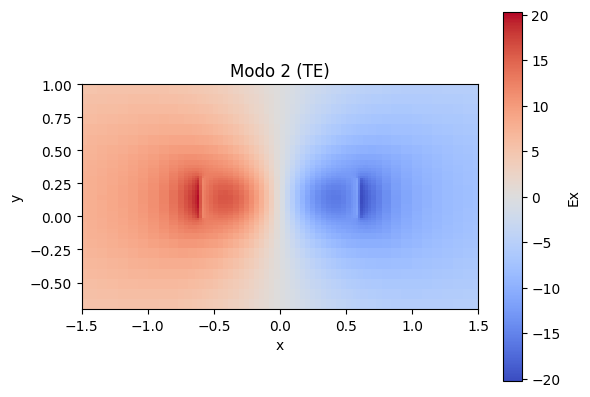

In [11]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
plt.title('Modo 2 (TE)')

Text(0.5, 1.0, 'Modo 3 (TM)')

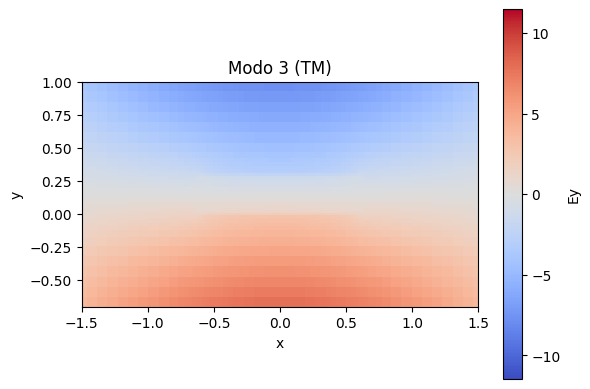

In [12]:
deep_waveguide.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
plt.title('Modo 3 (TM)')

**Important** 
These results are derived from a numerical method used to solve the EM problem, so they must always be interpreted carefully to assess their accuracy. You must check, for instance, if the value of each index neff is higher than the refractive index of the cladding. 

## LO.2. Wavelength behavior

- Let's find the wavelength dependence of the effective index of the SiNx deep waveguide described in LO1. Change the wavelength used at the waveguide cross-section function, it could be a vector also. 

2026-03-12 18:33:21.116 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e70065e5b5dc42c3.npz.
deep wg res_neff[[1.61596895+9.88144988e-05j 1.53547425+1.79500078e-04j
  1.45733645+1.89606238e-04j 1.43603378+2.25429090e-04j]
 [1.61371946+9.92694266e-05j 1.53375322+1.79215398e-04j
  1.4558689 +1.90616374e-04j 1.43570375+2.23960528e-04j]
 [1.61148949+9.97183026e-05j 1.53206461+1.78917441e-04j
  1.45448678+1.91492131e-04j 1.4353721 +2.22512036e-04j]
 [1.60927904+1.00161081e-04j 1.53040803+1.78606688e-04j
  1.45318485+1.92231508e-04j 1.43503881+2.21083228e-04j]
 [1.60708809+1.00597716e-04j 1.52878304+1.78283605e-04j
  1.45195773+1.92835224e-04j 1.43470387+2.19673757e-04j]
 [1.60491662+1.01028160e-04j 1.52718923+1.77948644e-04j
  1.45079998+1.93306400e-04j 1.43436726+2.18283247e-04j]
 [1.60276464+1.01452368e-04j 1.5256262 +1.77602240e-04j
  1.44970624+1.93650139e-04j 1.43402896+2.16911331e-04j]
 [1.60063211+1.01870294e-04j 1.52409351+1.77244815e-04j
  1.44867131

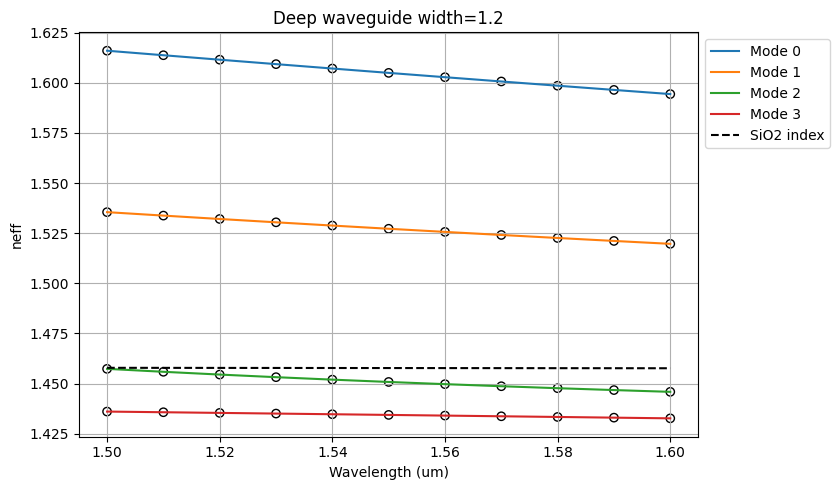

In [13]:
# The wavelength could be a vector also
wavelength = np.linspace(1.5, 1.6, 11)  # en µm, paso de 0.01

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = deep_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector

#Prints para interpretar resultados
print(f"deep wg res_neff{res_neff}")
print(f"deep wg res_te{res_te}")
print(f"deep wg res_tm{res_tm}")

plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
plt.title(f"Deep waveguide width={1.2}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
# Common error: The box index variable was created in a previous cell. Check the dimensions match 
# with the newly created wavelength vector, or re-calculate the box index for the new one. 
plt.plot(wavelength, box_index,'k--', label='SiO2 index') 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

2026-03-12 18:33:21.435 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cf0af488213d9e23.npz.
shallow wg res_neff [[1.63373911+9.42865373e-05j 1.54890418+1.54227267e-04j
  1.54327942+1.71392819e-04j 1.53284598+1.54057273e-04j]
 [1.63177064+9.46260838e-05j 1.54743434+1.53467005e-04j
  1.54180498+1.71803776e-04j 1.53156481+1.53627592e-04j]
 [1.62982164+9.49593327e-05j 1.54600001+1.52731771e-04j
  1.5403501 +1.72150028e-04j 1.53029371+1.53193960e-04j]
 [1.62789202+9.52863033e-05j 1.54459974+1.52025529e-04j
  1.53891463+1.72429923e-04j 1.52903228+1.52756561e-04j]
 [1.62598171+9.56070148e-05j 1.54323206+1.51350546e-04j
  1.53749853+1.72643381e-04j 1.52778012+1.52315582e-04j]
 [1.62409063+9.59214863e-05j 1.54189543+1.50707581e-04j
  1.53610185+1.72791702e-04j 1.52653684+1.51871190e-04j]
 [1.62221868+9.62297368e-05j 1.54058836+1.50096146e-04j
  1.53472471+1.72877314e-04j 1.52530203+1.51423543e-04j]
 [1.6203658 +9.65317852e-05j 1.53930937+1.49514800e-04j
  1.5333

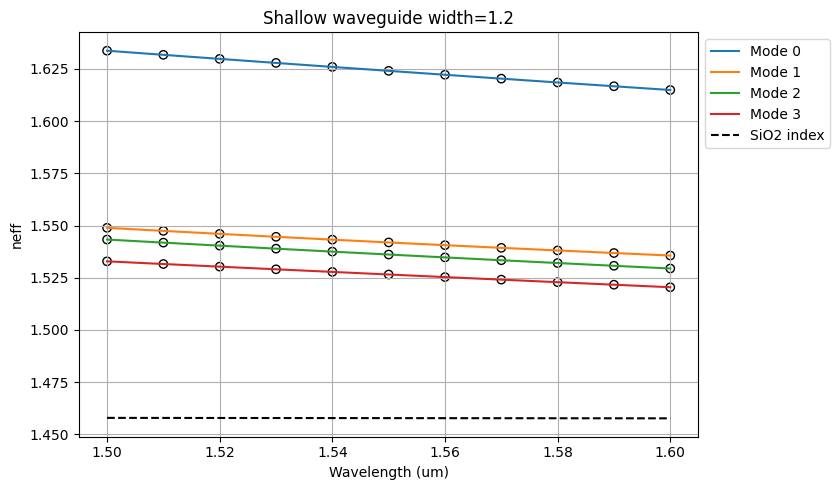

In [14]:
# Mismo proceso para la shallow wg
wavelength = np.linspace(1.5, 1.6, 11)  #mismas longitudes de onda

shallow_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=150 * nm,     # shallow → 150nm slab
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

shw_neff = shallow_waveguide.n_eff
shw_te = shallow_waveguide.fraction_te
shw_tm = shallow_waveguide.fraction_tm

#Prints para interpretar resultados
print(f"shallow wg res_neff {shw_neff}")
print(f"shallow wg res_te {shw_te}")
print(f"shallow wg res_tm {shw_tm}")

plt.figure(figsize=(10, 5))
for k in range(shallow_waveguide.n_eff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, shw_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, shw_neff[:,k].real,label=f'Mode {k}')
plt.title(f"Shallow waveguide width={1.2}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
# Common error: The box index variable was created in a previous cell. Check the dimensions match 
# with the newly created wavelength vector, or re-calculate the box index for the new one. 
plt.plot(wavelength, box_index,'k--', label='SiO2 index') 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

- Repeat the analysis for a **shallow**ly etched waveguide with a 150 nm slab heigth. 

## LO.3. Width dependence

- Perform a sweep of the **deep** waveguide width. Use the code provided in the following cell or program your own sweep. 

  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-12 18:33:21.654 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_203585dc557d3766.npz.
2026-03-12 18:33:21.658 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_01f69bbe128ede1f.npz.
2026-03-12 18:33:21.660 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c2d44042827f342b.npz.
2026-03-12 18:33:21.662 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_16185d8543a964fc.npz.
2026-03-12 18:33:21.663 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f0828f6f78af6364.npz.
2026-03-12 18:33:21.666 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24b1327d73545743.npz.
2026-03-12 18:33:21.670 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7a43e41c2f043e6e.npz.
2026-03-12 18:33:21.673 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6b3d22a1249d0932.npz.


  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-12 18:33:21.696 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_203585dc557d3766.npz.
2026-03-12 18:33:21.699 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_01f69bbe128ede1f.npz.
2026-03-12 18:33:21.702 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c2d44042827f342b.npz.
2026-03-12 18:33:21.708 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_16185d8543a964fc.npz.
2026-03-12 18:33:21.711 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f0828f6f78af6364.npz.
2026-03-12 18:33:21.715 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24b1327d73545743.npz.
2026-03-12 18:33:21.719 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7a43e41c2f043e6e.npz.
2026-03-12 18:33:21.721 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6b3d22a1249d0932.npz.


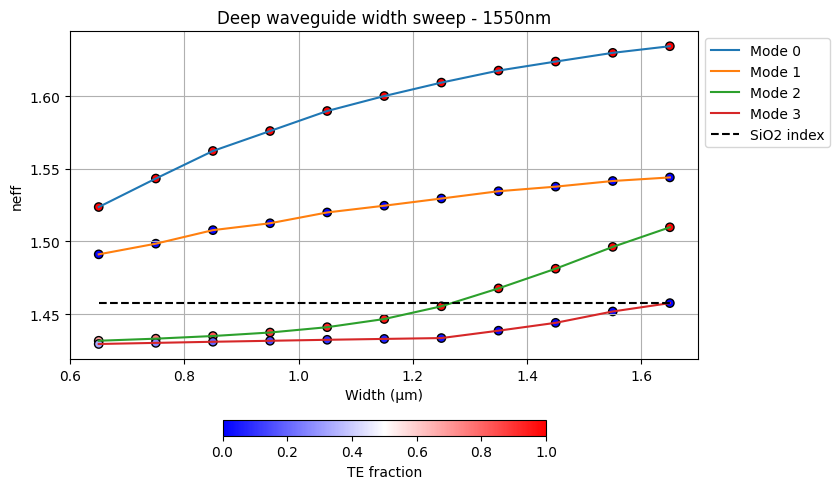

,Mode 0,Mode 1,Mode 2,Mode 3
w (µm),,,,
0.65,1.523715,1.491148,1.431673,1.429440
0.75,1.543334,1.498498,1.433108,1.430212
0.85,1.562305,1.507810,1.434933,1.430973
0.95,1.576030,1.512551,1.437349,1.431652
1.05,1.589804,1.519986,1.441006,1.432338
1.15,1.600107,1.524630,1.446633,1.432943
1.25,1.609365,1.529579,1.455396,1.433528
1.35,1.617630,1.534598,1.467727,1.438609
1.45,1.623837,1.537742,1.481266,1.444017


,Mode 0,Mode 1,Mode 2,Mode 3
w (µm),,,,
0.65,0.989,0.012,0.690,0.335
0.75,0.990,0.012,0.772,0.262
0.85,0.992,0.012,0.838,0.196
0.95,0.992,0.011,0.895,0.139
1.05,0.994,0.011,0.933,0.095
1.15,0.994,0.010,0.956,0.064
1.25,0.995,0.010,0.970,0.043
1.35,0.996,0.009,0.978,0.011
1.45,0.997,0.008,0.982,0.012


In [15]:
wavelength = 1.55  # Lambda fija

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

w = np.linspace(0.65, 1.65, 11)
w_labels = [f'{wi:.2f}' for wi in w]

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, core_width=w)
sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide, core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:, k].real, edgecolors='k', c=sweep_tefraction.sel(mode_index=k), vmin=0, vmax=1, label='__nolegend__', cmap='bwr')
    plt.plot(w, sweep_neff[:, k].real, label=f'Mode {k}')
plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (µm)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal', fraction=0.04).set_label("TE fraction")
plt.show()

import pandas as pd

# Tabla neff
neff_data = {f'Mode {mode}': sweep_neff[:, mode].real for mode in range(sweep_neff.shape[1])}
df_neff = pd.DataFrame(neff_data, index=w_labels)
df_neff.index.name = 'w (µm)'

display(df_neff.style
    .format("{:.6f}")
    .background_gradient(cmap='Blues', axis=None)
    .set_caption("neff vs Width — Deep Waveguide @ 1550nm")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '12px'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px 12px'), ('font-size', '11px')]},
        {'selector': 'tr:hover td', 'props': [('background-color', '#f0f4ff !important')]},
    ])
)

# Tabla fraction_TE
te_data = {f'Mode {mode}': sweep_tefraction[:, mode].values for mode in range(4)}
df_te = pd.DataFrame(te_data, index=w_labels)
df_te.index.name = 'w (µm)'

display(df_te.style
    .format("{:.3f}")
    .background_gradient(cmap='RdBu', vmin=0, vmax=1, axis=None)
    .set_caption("TE Fraction vs Width — Deep Waveguide @ 1550nm")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '12px'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px 12px'), ('font-size', '11px')]},
        {'selector': 'tr:hover td', 'props': [('background-color', '#fff8f0 !important')]},
    ])
)

## LO.4. Waveguide compact model

A compact model of an integrated photonic waveguide is a reduced-order mathematical model that describes the waveguide’s optical behavior—such as phase propagation, loss, and dispersion, using analytical or semi-analytical equations. Consider: 

Consider: 

The transfer function for propagation in a waveguide:

$$
H(\lambda)
= e^{-j\,\gamma(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\gamma(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\gamma(\lambda)\}\,z}.
$$

Where 

$$
\beta(\lambda) = \mathrm{Re}\{\gamma(\lambda)\}\,z
= \frac{2\pi}{\lambda}\,n_\mathrm{eff}(\lambda).
$$

Let's model the waveguide's effective index wavelength variation using a second order polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Where 

1. 
$$
n_\mathrm{eff}(\lambda_0) = n_1
$$
2. 
$$
n_g(\lambda_0) = n_1 - n_2\,\lambda_0
$$
3. 
$$
D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

- Find the values for n, ng and D of the following waveguides: 
    - Deep waveguide, height = 300nm, width = 1.2um 
    - Shallow waveguide, core height = 300nm, slab height = 150 nm, width = 1.2um 

**TIP**. Use the Lab0.1.Modesolver results (neff vs lambda) as starting point. Fit the results using a second order polynomial (with the lambda_0 shift) and relate the fit results to n_g and D values.

=== Deep TE0 ===
  n1 (neff at λ0) = 1.604917
  ng              = 1.939991
  D               = -1.006e+03 ps²/m
=== Deep TM0 ===
  n1 (neff at λ0) = 1.527189
  ng              = 1.772025
  D               = -1.590e+03 ps²/m


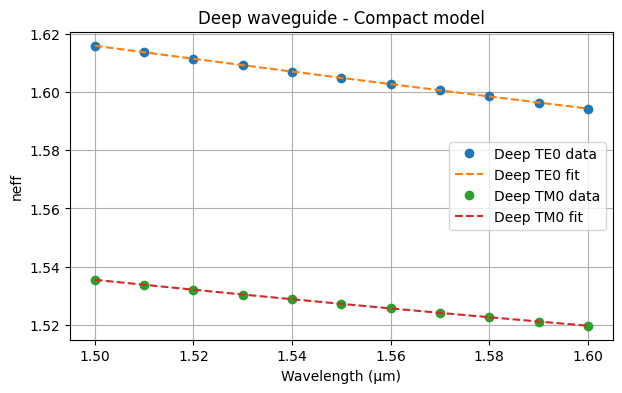

=== Shallow TE0 ===
  n1 (neff at λ0) = 1.624091
  ng              = 1.915762
  D               = -9.889e+02 ps²/m
=== Shallow TM0 ===
  n1 (neff at λ0) = 1.526537
  ng              = 1.718756
  D               = -4.389e+02 ps²/m


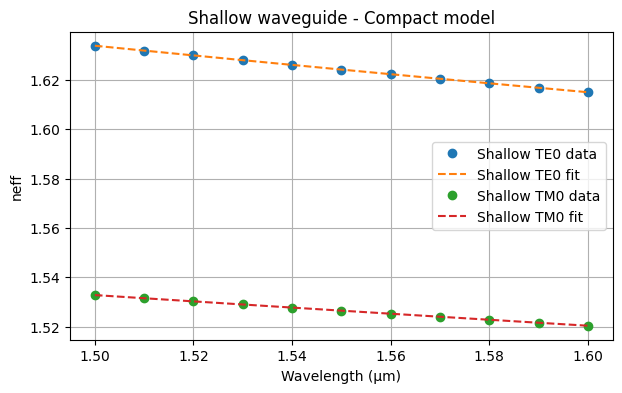

In [16]:
wavelength = np.linspace(1.5, 1.6, 11)
wavelength_m = wavelength * 1e-6
lambda_0_m = 1.55e-6
c = 3e8

cases_deep = {
    'Deep TE0': res_neff[:, 0].real,
    'Deep TM0': res_neff[:, 1].real,
}
cases_shallow = {
    'Shallow TE0': shw_neff[:, 0].real,
    'Shallow TM0': shw_neff[:, 3].real,
}

# Diccionario global para guardar resultados
fit_results = {}

def fit_and_plot(cases, title):
    plt.figure(figsize=(7, 4))
    for name, neff_vec in cases.items():
        lam_centered = wavelength - 1.55
        coeffs = np.polyfit(lam_centered, neff_vec, 2)
        n3, n2, n1 = coeffs

        ng = n1 - n2 * 1.55
        D  = -2 * lambda_0_m * 1e18 * n3 / c

        # Guardar resultados
        fit_results[name] = {'neff (λ₀)': n1, 'ng (λ₀)': ng, 'D (ps²/m)': D}

        print(f"=== {name} ===")
        print(f"  n1 (neff at λ0) = {n1:.6f}")
        print(f"  ng              = {ng:.6f}")
        print(f"  D               = {D:.3e} ps²/m")

        neff_fit = np.polyval(coeffs, lam_centered)
        plt.plot(wavelength, neff_vec, 'o', label=f'{name} data')
        plt.plot(wavelength, neff_fit, '--', label=f'{name} fit')

    plt.xlabel('Wavelength (µm)')
    plt.ylabel('neff')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

fit_and_plot(cases_deep,    'Deep waveguide - Compact model')
fit_and_plot(cases_shallow, 'Shallow waveguide - Compact model')

# ── TABLA ──────────────────────────────────────────────────────────────────
import pandas as pd

df_lo4 = pd.DataFrame(fit_results).T
df_lo4.index.name = 'Mode'

# Separar Waveguide y Mode en MultiIndex
df_lo4.index = pd.MultiIndex.from_tuples(
    [(n.split()[0], n.split()[1]) for n in df_lo4.index],
    names=['Waveguide', 'Mode']
)

display(df_lo4.style
    .format({'neff (λ₀)': '{:.6f}', 'ng (λ₀)': '{:.6f}', 'D (ps²/m)': '{:.3e}'})
    .background_gradient(cmap='coolwarm', subset=['D (ps²/m)'], axis=None)
    .set_caption("Compact Model Parameters — SiNx Waveguides @ λ₀=1.55µm")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '12px'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px 14px'), ('font-size', '11px')]},
        {'selector': 'tr:hover td', 'props': [('background-color', '#f0f4ff !important')]},
    ])
)

## LO.5. Bend waveguide radius vs. loss – deep

The bend loss has three primary contributions:

1. Mode-mismatch loss
2. Radiation loss
3. Propagation loss

  0%|          | 0/6 [00:00<?, ?it/s]

/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

18:33:46 CET WARNING: The group index was not computed. To calculate group      
             index, pass 'group_index_step = True' in the 'ModeSpec'.           

2026-03-12 18:33:46.282 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_1592dba1d8e935a8.npz.


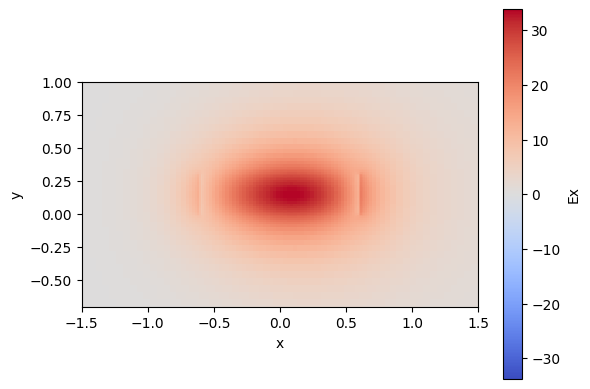

In [17]:
radii = np.array([25, 50, 75, 100, 125, 150])  # µm

bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=1.2,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=20, # Bend radius
)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

bend_1550.plot_field(field_name="Ex", 
                     mode_index=0, # Field to be plotted
                     value='real', # Real - abs - imag
                     cmap='coolwarm',
                     xlim=(-1.5, 1.5), # Set the x and y limits
                     ylim=(-0.7, 1)) 

### Mode-mismatch loss

Bend waveguide mode differs slightly from the straight waveguide mode, wich yield into mode-convertion losses. We can calculate this factor with as the overlap of the latter two modes. 

This is already implemented on GDSfactory library: 

In [ ]:
# radii = np.arange(20.0, 120,11)
radii = np.array([25, 50, 75, 100, 125, 150])

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

plt.plot(radii, 10 * np.log10(mismatch))
plt.title("Strip waveguide bend")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch (dB)")

  0%|          | 0/6 [00:00<?, ?it/s]

/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

### Propagation loss

Consider the equivalent linear length of the quarter-circle bend. Light will attenuate following a trend quantified with the experimentally measured parameter $$\alpha [\mathrm{dB}/\mathrm{cm}]$$. It depends on the fabrication process mainly. We will add this loss (in dBs) to the mode-mismatch loss to calculate the total loss per bend. 

*We are not considering the radiation losses, mainly because is not easy to implement a quick simulation for this parameter. Under certain conditions, the main loss sources are the ones considered in this example


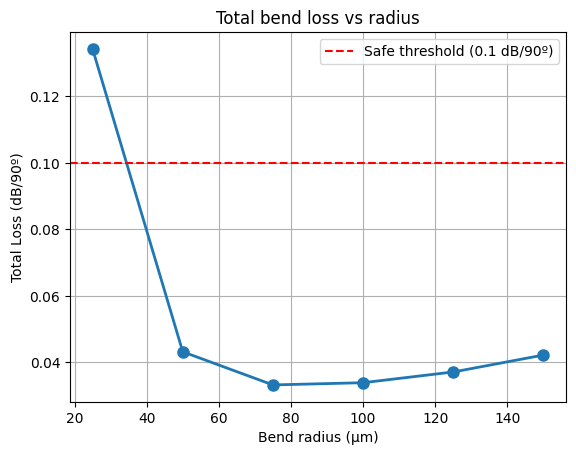

=== Total loss per radius ===
R =  25 µm: 0.1343 dB/90º ✗ UNSAFE
R =  50 µm: 0.0432 dB/90º ✓ SAFE
R =  75 µm: 0.0332 dB/90º ✓ SAFE
R = 100 µm: 0.0339 dB/90º ✓ SAFE
R = 125 µm: 0.0371 dB/90º ✓ SAFE
R = 150 µm: 0.0422 dB/90º ✓ SAFE


In [ ]:
dB_cm = 1.5  # dB/cm Technology loss
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
mode_loss = -10 * np.log10(mismatch)
total_loss = propagation_loss + mode_loss

# Plot Total Loss vs R
plt.figure()
plt.plot(radii, total_loss, 'o-', linewidth=2, markersize=8)
plt.axhline(0.1, color='r', linestyle='--', label='Safe threshold (0.1 dB/90º)')
plt.xlabel('Bend radius (µm)')
plt.ylabel('Total Loss (dB/90º)')
plt.title('Total bend loss vs radius')
plt.legend()
plt.grid()
plt.show()

# Print radio seguro
print("=== Total loss per radius ===")
for r, loss in zip(radii, total_loss):
    safe = "✓ SAFE" if loss < 0.1 else "✗ UNSAFE"
    print(f"R = {r:3.0f} µm: {loss:.4f} dB/90º {safe}")

2026-03-12 12:05:54.483 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from /home/ldespuc/.gdsfactory/modes/Waveguide_858c4a98c7974307.npz.
2026-03-12 12:05:54.487 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from /home/ldespuc/.gdsfactory/modes/Waveguide_44c5603cd7958d04.npz.
2026-03-12 12:05:54.491 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from /home/ldespuc/.gdsfactory/modes/Waveguide_290ec48d630de3b8.npz.
2026-03-12 12:05:54.495 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from /home/ldespuc/.gdsfactory/modes/Waveguide_c23b2a49e27ee5e0.npz.
2026-03-12 12:05:54.499 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from /home/ldespuc/.gdsfactory/modes/Waveguide_33a8a1e415ee3b49.npz.
2026-03-12 12:05:54.504 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from /home/ldespuc/.gdsfactory/modes/Waveguide_e2c8a7e2a646ff62.npz.


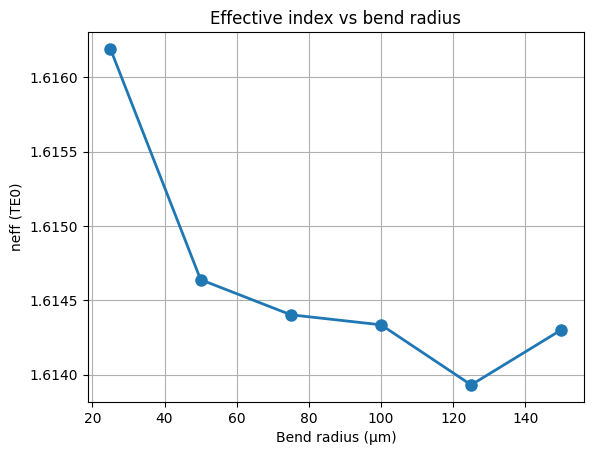

In [ ]:
# Plot neff_TE0 vs R
neff_vs_R = []
for r in radii:
    bend = gt.modes.Waveguide(
        wavelength=1550 * nm,
        core_width=1.2,
        slab_thickness=0.0,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=1,
        bend_radius=r,
        grid_resolution=30,
    )
    neff_vs_R.append(bend.n_eff.real)  # SIN [0]

plt.figure()
plt.plot(radii, neff_vs_R, 'o-', linewidth=2, markersize=8)
plt.xlabel('Bend radius (µm)')
plt.ylabel('neff (TE0)')
plt.title('Effective index vs bend radius')
plt.grid()
plt.show()

- Use the code provided in this section to calculate the safe radius for 1.2 um width deep waveguides at 1.5 um. Consider safe means less than 0.1 dB/90º

## EXTRA

All the past simulations were done considering as core material de Silicon Nitride (SiNx) and Silicon Dioxide (SiO2) as cladding material. Now, **simulate the Silicon-On-Insulator technology changing the core material to Silicon (Si)**. In this case, the dimensions will be 220 nm heigth and 500 nm width. 
1. Repeat the LO.2. wavelength behavior simulations, considering the updated materials and dimensions. 
2. Repeat the LO.3. width dependence analysis, now sweeping in a 300nm - 1um range. 
3. Find the safe radius for this technology. Consider sweeping the radius in a 5um to 30um range. 
4. **Compare the SiNx and SOI technologies** 

2026-03-12 12:05:54.615 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_38091c594b211d32.npz.


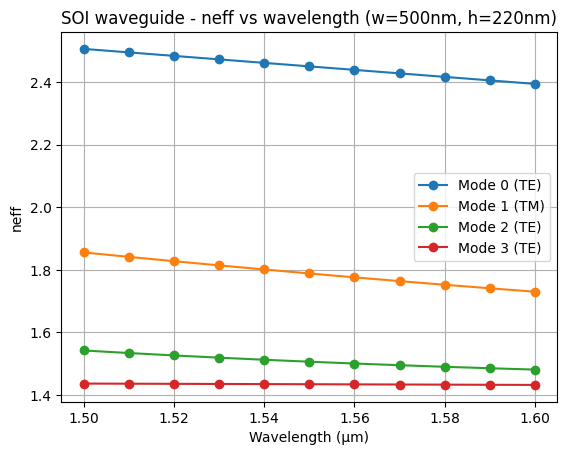

=== SOI neff at λ=1.55µm ===
Mode 0 (TE): neff = 2.4499
Mode 1 (TM): neff = 1.7884
Mode 2 (TE): neff = 1.5066
Mode 3 (TE): neff = 1.4346


,Polarization,neff @ 1.55µm,fraction_te
Mode,,,
Mode 0,TE,2.4499,0.9783
Mode 1,TM,1.7884,0.0607
Mode 2,TE,1.5066,0.7210
Mode 3,TE,1.4346,0.9934


In [ ]:
wavelength = np.linspace(1.5, 1.6, 11)

soi_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=0.5,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

soi_neff = soi_waveguide.n_eff
soi_te = soi_waveguide.fraction_te
soi_tm = soi_waveguide.fraction_tm

# Plot
plt.figure()
for mode in range(4):
    pol = "TE" if soi_te[mode] > 0.5 else "TM"  # SIN [5, ]
    plt.plot(wavelength, soi_neff[:, mode].real, 'o-', label=f'Mode {mode} ({pol})')
plt.xlabel('Wavelength (µm)')
plt.ylabel('neff')
plt.title('SOI waveguide - neff vs wavelength (w=500nm, h=220nm)')
plt.legend()
plt.grid()
plt.show()

print("=== SOI neff at λ=1.55µm ===")
for mode in range(4):
    pol = "TE" if soi_te[mode] > 0.5 else "TM"
    print(f"Mode {mode} ({pol}): neff = {soi_neff[5, mode].real:.4f}")

import pandas as pd

soi_data = {}
for mode in range(4):
    pol = "TE" if soi_te[mode] > 0.5 else "TM"
    soi_data[f'M{mode} ({pol})'] = soi_neff[:, mode].real

df_soi_wl = pd.DataFrame(soi_data, index=[f'{wl:.2f}' for wl in wavelength])
df_soi_wl.index.name = 'λ (µm)'


df_soi_1550 = pd.DataFrame({
    'Mode': [f'Mode {m}' for m in range(4)],
    'Polarization': ['TE' if soi_te[m] > 0.5 else 'TM' for m in range(4)],
    'neff @ 1.55µm': [soi_neff[5, m].real for m in range(4)],
    'fraction_te': [soi_te[m] for m in range(4)]
}).set_index('Mode')

display(df_soi_1550.style
    .format({'neff @ 1.55µm': '{:.4f}', 'fraction_te': '{:.4f}'})
    .background_gradient(cmap='Blues', subset=['neff @ 1.55µm'], axis=None)
    .background_gradient(cmap='RdBu', subset=['fraction_te'], vmin=0, vmax=1, axis=None)
    .set_caption("SOI — neff @ λ=1.55µm (w=500nm, h=220nm)")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#1a3a4a'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px 14px'), ('font-size', '11px')]},
        {'selector': 'tr:hover td', 'props': [('background-color', '#f0f4ff !important')]},
    ])
)

  0%|          | 0/8 [00:00<?, ?it/s]

2026-03-12 12:15:28.383 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_58b0951888c2c7de.npz.


/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

12:15:34 CET WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: The group index was not computed. To calculate group      
             index, pass 'group_index_step = True' in the 'ModeSpec'.           

2026-03-12 12:15:34.513 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_ce81d30082f5cfc5.npz.
2026-03-12 12:15:34.537 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_223d93916735b32f.npz.
2026-03-12 12:15:34.540 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_401cb9732cf25023.npz.
2026-03-12 12:15:34.545 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_31626027bb3dd9b4.npz.
2026-03-12 12:15:34.549 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24197408d3d2932f.npz.
2026-03-12 12:15:34.554 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2e78eba690755aa1.npz.
2026-03-12 12:15:34.558 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_07b520dc17f68bb3.npz.


  0%|          | 0/8 [00:00<?, ?it/s]

2026-03-12 12:15:34.574 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_58b0951888c2c7de.npz.
2026-03-12 12:15:34.577 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ce81d30082f5cfc5.npz.
2026-03-12 12:15:34.581 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_223d93916735b32f.npz.
2026-03-12 12:15:34.584 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_401cb9732cf25023.npz.
2026-03-12 12:15:34.590 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_31626027bb3dd9b4.npz.
2026-03-12 12:15:34.593 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24197408d3d2932f.npz.
2026-03-12 12:15:34.597 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2e78eba690755aa1.npz.
2026-03-12 12:15:34.599 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_07b520dc17f68bb3.npz.


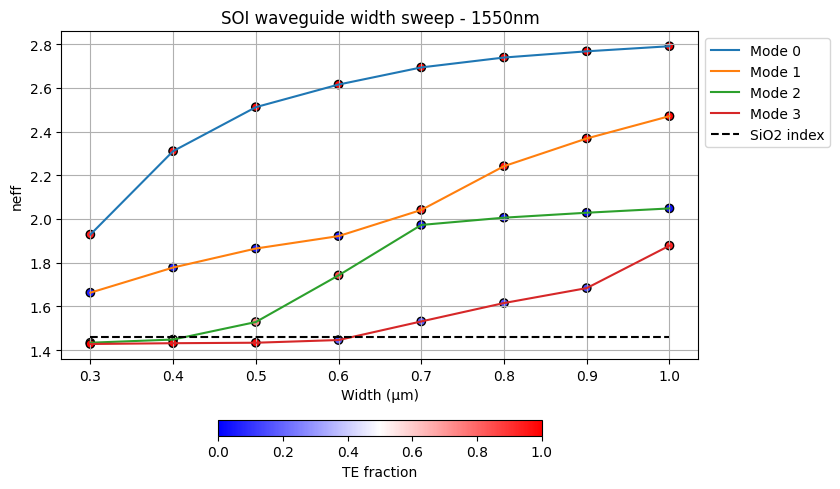

,Mode 0,Mode 1,Mode 2,Mode 3
w (µm),,,,
0.30,1.928550,1.662646,1.433804,1.427887
0.40,2.310111,1.777654,1.448264,1.431525
0.50,2.511347,1.864636,1.528382,1.433691
0.60,2.614776,1.921492,1.741861,1.445996
0.70,2.693138,2.041125,1.972539,1.531157
0.80,2.738404,2.241400,2.005785,1.615297
0.90,2.766853,2.368166,2.028386,1.683602
1.00,2.790134,2.470181,2.048045,1.877769


,Mode 0,Mode 1,Mode 2,Mode 3
w (µm),,,,
0.30,0.937,0.066,0.533,0.998
0.40,0.966,0.063,0.613,0.999
0.50,0.982,0.058,0.746,0.992
0.60,0.988,0.052,0.862,0.185
0.70,0.994,0.942,0.047,0.180
0.80,0.996,0.969,0.041,0.162
0.90,0.997,0.978,0.038,0.147
1.00,0.998,0.986,0.034,0.924


In [ ]:
wavelength = 1.55  # µm fijo

soi_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=0.5,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

w = np.linspace(0.3, 1.0, 8)
w_labels = [f'{wi:.2f}' for wi in w]  # índice único para todas las tablas
sweep_neff_soi = gt.modes.sweep_n_eff(soi_waveguide, core_width=w)
sweep_tefraction_soi = gt.modes.sweep_fraction_te(soi_waveguide, core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff_soi.shape[1]):
    plt.scatter(w, sweep_neff_soi[:, k].real, edgecolors='k', c=sweep_tefraction_soi.sel(mode_index=k), vmin=0, vmax=1, label='__nolegend__', cmap='bwr')
    plt.plot(w, sweep_neff_soi[:, k].real, label=f'Mode {k}')
plt.title("SOI waveguide width sweep - 1550nm")
plt.xlabel("Width (µm)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal', fraction=0.04).set_label("TE fraction")
plt.show()

import pandas as pd

# Tabla neff
neff_data_soi = {f'Mode {mode}': sweep_neff_soi[:, mode].real for mode in range(sweep_neff_soi.shape[1])}
df_neff_soi = pd.DataFrame(neff_data_soi, index=w_labels)
df_neff_soi.index.name = 'w (µm)'

display(df_neff_soi.style
    .format("{:.6f}")
    .background_gradient(cmap='Blues', axis=None)
    .set_caption("SOI — neff vs Width (h=220nm, λ=1.55µm)")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#1a3a4a'), ('color', 'white'), ('font-size', '12px'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px 12px'), ('font-size', '11px')]},
        {'selector': 'tr:hover td', 'props': [('background-color', '#f0f4ff !important')]},
    ])
)

# Tabla fraction_TE
te_data_soi = {f'Mode {mode}': sweep_tefraction_soi[:, mode].values for mode in range(4)}
df_te_soi = pd.DataFrame(te_data_soi, index=w_labels)
df_te_soi.index.name = 'w (µm)'

display(df_te_soi.style
    .format("{:.3f}")
    .background_gradient(cmap='RdBu', vmin=0, vmax=1, axis=None)
    .set_caption("SOI — TE Fraction vs Width (h=220nm, λ=1.55µm)")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#1a3a4a'), ('color', 'white'), ('font-size', '12px'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px 12px'), ('font-size', '11px')]},
        {'selector': 'tr:hover td', 'props': [('background-color', '#fff8f0 !important')]},
    ])
)

  0%|          | 0/6 [00:00<?, ?it/s]

/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

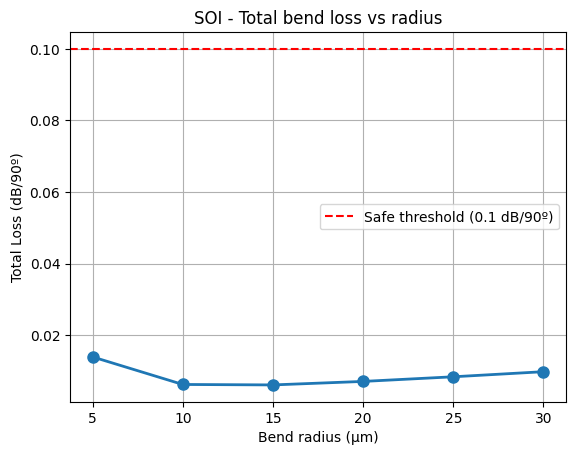

2026-03-12 12:29:11.527 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from /home/ldespuc/.gdsfactory/modes/Waveguide_6972b88766985bd8.npz.


/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

2026-03-12 12:29:17.697 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into /home/ldespuc/.gdsfactory/modes/Waveguide_f34c174eccb739ef.npz.


/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

2026-03-12 12:29:20.319 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into /home/ldespuc/.gdsfactory/modes/Waveguide_44575169fd8f2a6c.npz.


...

2026-03-12 12:29:30.778 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into /home/ldespuc/.gdsfactory/modes/Waveguide_c3d62c6b54818fe7.npz.


/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

2026-03-12 12:29:37.984 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into /home/ldespuc/.gdsfactory/modes/Waveguide_912474298c0062df.npz.


/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/ldespuc/lab0-install/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

2026-03-12 12:29:48.611 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into /home/ldespuc/.gdsfactory/modes/Waveguide_c4401ee08624f4d8.npz.


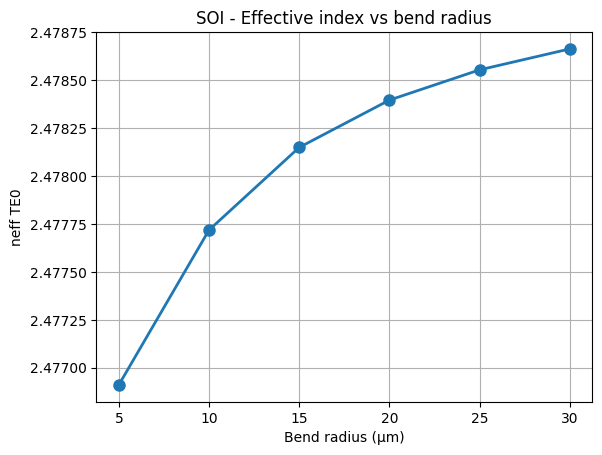

=== SOI - Total loss per radius ===
R =   5 µm: 0.0139 dB/90º ✓ SAFE
R =  10 µm: 0.0062 dB/90º ✓ SAFE
R =  15 µm: 0.0061 dB/90º ✓ SAFE
R =  20 µm: 0.0070 dB/90º ✓ SAFE
R =  25 µm: 0.0083 dB/90º ✓ SAFE
R =  30 µm: 0.0098 dB/90º ✓ SAFE


In [ ]:
radii_soi = np.arange(5, 31, 5)  # 5 a 30µm, step 5µm

bend_soi = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=0.5,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=1,
    grid_resolution=30,
)

mismatch_soi = gt.modes.sweep_bend_mismatch(bend_soi, radii_soi)

# Propagation loss
dB_cm = 2.0  # dB/cm para SOI (típicamente mayor que SiNx)
length_soi = 0.5 * np.pi * radii_soi * 1e-6
propagation_loss_soi = dB_cm * length_soi * 1e2
mode_loss_soi = -10 * np.log10(mismatch_soi)
total_loss_soi = propagation_loss_soi + mode_loss_soi

# Plot
plt.figure()
plt.plot(radii_soi, total_loss_soi, 'o-', linewidth=2, markersize=8)
plt.axhline(0.1, color='r', linestyle='--', label='Safe threshold (0.1 dB/90º)')
plt.xlabel('Bend radius (µm)')
plt.ylabel('Total Loss (dB/90º)')
plt.title('SOI - Total bend loss vs radius')
plt.legend()
plt.grid()
plt.show()


# Plot neff vs bend radius
neff_vs_R_soi = []
for r in radii_soi:
    bend = gt.modes.Waveguide(
        wavelength=1550 * nm,
        core_width=0.5,
        slab_thickness=0.0,
        core_material='si',
        clad_material='sio2',
        core_thickness=220 * nm,
        num_modes=1,
        bend_radius=r,
        grid_resolution=30,
    )
    neff_vs_R_soi.append(float(bend.n_eff.real))

plt.figure()
plt.plot(radii_soi, neff_vs_R_soi, 'o-', linewidth=2, markersize=8)
plt.xlabel('Bend radius (µm)')
plt.ylabel('neff TE0')
plt.title('SOI - Effective index vs bend radius')
plt.grid()
plt.show()
# Print
print("=== SOI - Total loss per radius ===")
for r, loss in zip(radii_soi, total_loss_soi):
    safe = "✓ SAFE" if loss < 0.1 else "✗ UNSAFE"
    print(f"R = {r:3.0f} µm: {loss:.4f} dB/90º {safe}")

In [ ]:
print("="*60)
print("COMPARACIÓN SiNx vs SOI")
print("="*60)
print("\n1. MATERIALES Y DIMENSIONES:")
print("   SiNx: core=1.99, w=1.2µm, h=300nm")
print("   SOI:  core=3.48, w=500nm, h=220nm")

print("\n2. ÍNDICE EFECTIVO (TE0 @ 1.55µm):")
print(f"   SiNx: neff = 1.605")
print(f"   SOI:  neff = 2.450 (+53% mayor confinamiento)")

print("\n3. SENSIBILIDAD AL ANCHO:")
print("   SiNx: Δneff = 0.12 (w: 0.6-1.6µm)")
print("   SOI:  Δneff = 0.86 (w: 0.3-1.0µm) → 7x más sensible")

print("\n4. RADIO DE CURVATURA SEGURO (<0.1 dB/90º):")
print("   SiNx: R ≥ 50 µm")
print("   SOI:  R ≥ 5 µm → 10x más compacto")

print("\n5. DISPERSIÓN (TE0):")
print("   SiNx: D = -1.01×10⁻³ ps²/m")
print("   SOI:  [ejecutar LO.4 para SOI si quieres este dato]")

print("\n6. VENTAJAS/DESVENTAJAS:")
print("   SiNx: + Menor sensibilidad dimensional (fabricación más tolerante)")
print("         + Compatible con CMOS backend")
print("         - Radios grandes → chips más grandes")
print("   SOI:  + Radios ultra-compactos → alta densidad de integración")
print("         + Mayor ancho de banda modal")
print("         - Muy sensible a variaciones de fabricación")
print("         - Mayor pérdida por rugosidad de borde")
print("="*60)

COMPARACIÓN SiNx vs SOI

1. MATERIALES Y DIMENSIONES:
   SiNx: core=1.99, w=1.2µm, h=300nm
   SOI:  core=3.48, w=500nm, h=220nm

2. ÍNDICE EFECTIVO (TE0 @ 1.55µm):
   SiNx: neff = 1.605
   SOI:  neff = 2.450 (+53% mayor confinamiento)

3. SENSIBILIDAD AL ANCHO:
   SiNx: Δneff = 0.12 (w: 0.6-1.6µm)
   SOI:  Δneff = 0.86 (w: 0.3-1.0µm) → 7x más sensible

4. RADIO DE CURVATURA SEGURO (<0.1 dB/90º):
   SiNx: R ≥ 50 µm
   SOI:  R ≥ 5 µm → 10x más compacto

5. DISPERSIÓN (TE0):
   SiNx: D = -1.01×10⁻³ s²/m
   SOI:  [ejecutar LO.4 para SOI si quieres este dato]

6. VENTAJAS/DESVENTAJAS:
   SiNx: + Menor sensibilidad dimensional (fabricación más tolerante)
         + Compatible con CMOS backend
         - Radios grandes → chips más grandes
   SOI:  + Radios ultra-compactos → alta densidad de integración
         + Mayor ancho de banda modal
         - Muy sensible a variaciones de fabricación
         - Mayor pérdida por rugosidad de borde


## Grading

LO.1. 1 Point <br> 
LO.2. 2 Points <br> 
LO.3. 1 Point <br> 
LO.4. 2 Points <br> 
LO.5. 1 Point <br> 
**Total 7 Points** <br>
Extra (Up to) 3 Points
